In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data

In [2]:
def read_parquet(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return user_chunk_df

In [3]:
def read_parquet_item(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    item_chunk_files = [file for file in files if 'item_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return item_chunk_df

In [4]:
def read_parquet_purchase(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    purchase_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    purchase_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_chunk_files]) if purchase_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return purchase_chunk_df

In [6]:
trans_df = read_parquet_purchase(".././preprocessed-dataset")
trans_df

item_id,quantity,customer_id,created_date,location,price,log_price,discount_rate,channel,payment_bucket,time_between_purchases,month,seasonal_trend,product_engagement_level
str,i32,i32,datetime[μs],i32,f64,f64,f64,str,str,duration[μs],i8,str,str
"""7115000000004""",1,5254214,2024-12-24 18:17:01.027,656,49000.0,10.799596,0.0,"""In-Store""","""qr""",316d 20h 50m 27s 623ms,12,"""Winter""","""High"""
"""0029130000030""",1,7573232,2024-12-24 19:28:01.870,143,69000.0,11.141876,0.0,"""In-Store""","""cash""",203d 1h 54m 54s 827ms,12,"""Winter""","""High"""
"""3496000000053""",2,8187418,2024-12-24 19:50:43.760,213,75000.0,11.225257,0.0,"""In-Store""","""wallet""",1m 4s 537ms,12,"""Winter""","""High"""
"""2700000000002""",2,8187418,2024-12-24 19:49:39.223,213,58500.0,10.976799,0.1,"""In-Store""","""wallet""",1m 4s 537ms,12,"""Winter""","""High"""
"""0029110000036""",1,6931560,2024-12-28 09:49:33.780,590,89000.0,11.396403,0.10101,"""Android""","""wallet""",354d 16h 9m 39s 93ms,12,"""Winter""","""High"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""0175000000011""",1,2083231,2024-12-09 17:37:34.450,697,69000.0,11.141876,0.0,"""In-Store""","""wallet""",325d 17h 52m 41s 606ms,12,"""Winter""","""High"""
"""5902000000002""",1,8141777,2024-12-09 08:01:39.743,353,115000.0,11.652696,0.0,"""In-Store""","""cash""",0µs,12,"""Winter""","""High"""
"""0175000000007""",1,8066612,2024-12-09 19:22:15.857,940,79000.0,11.277216,0.0,"""In-Store""","""cash""",17d 8h 6m 50s 280ms,12,"""Winter""","""High"""


In [7]:
item_df = read_parquet_item(".././preprocessed-dataset")
item_df.head()

item_id,price,category_l1,category,brand_final,target_user_group_final,item_type_final,color_final,origin_final,material_final,sale_status,description_merge,age_bucket_final,price_segment
str,"decimal[38,4]",str,str,str,str,str,str,str,str,i32,str,str,str
"""0502020000004""",99000.0000,"""Babycare""","""Núm ty Dr Brown""","""Dr.Brown's""","""Sơ sinh""",null,"""Đen""","""Ý""","""Silicone""",0,"""Chi tiết sản phẩm …","""1-3M""","""Mid"""
"""0010290040150""",69000.0000,"""Thời trang""","""Bộ quần áo bé gái""","""Con Cưng""","""Bé Gái""","""Bộ quần áo""",null,null,null,0,null,"""2-4Y""","""Mid"""
"""0008010000015""",45000.0000,"""Đồ chơi & Sách""","""Gặm nướu khác""","""Thương hiệu khác""","""Bé Trai""",null,"""Hồng""","""Đức""","""Silicone""",0,"""Chi tiết sản phẩm …",null,"""Low"""
"""0020010000094""",401000.0000,"""Tã""","""Merries_Sơ Sinh""","""Merries Nhật""","""Sơ sinh""",null,"""Đen""","""Nhật Bản, Nhật Bản""","""Giấy, bột giấy, vải không dệt,…",0,"""﻿﻿Tã dán Merries size S 82 miế…","""3-6M""","""High"""
"""0020010000098""",401000.0000,"""Tã""","""Merries_Tã Quần""","""Merries Nhật""","""Sơ sinh""",null,"""Đen""","""Nhật Bản, Nhật Bản""","""Giấy, bột giấy, vải không dệt,…",0,"""﻿﻿﻿Bỉm tã quần Merries size M …","""6-9M""","""High"""


In [8]:
user_df = read_parquet(".././preprocessed-dataset")
user_df.head()

customer_id,gender,location,province,membership,region,location_name,install_app,district
i32,str,i32,str,str,str,str,str,str
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""","""7"""
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""","""Thủ Đức"""
29718,"""Nữ""",157,"""Bến Tre""","""Standard""","""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""","""Bến Tre"""
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""","""1"""
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""","""Tân Phú"""


# Thực hiện yêu cầu đặc trưng 2

In [7]:
# Cell 1
import polars as pl
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans  # optional
# Assumes item_df and trans_df đã được load bằng polars trước đó
# item_df = pl.read_parquet("..."); trans_df = pl.read_parquet("...")
tx_orig = trans_df.clone()   # giữ nguyên bản gốc để join trả về
item = item_df.clone()


In [8]:
# Cell 2
tx = tx_orig.clone()  # working copy để thao tác
formats = [
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%dT%H:%M:%S",
    "%Y-%m-%d",
    "%d/%m/%Y %H:%M:%S",
    "%d/%m/%Y"
]

parsed_ok = False
for fmt in formats:
    try:
        parsed = tx.with_columns([
            pl.col("created_date").str.strptime(pl.Datetime, fmt, strict=False).alias("created_date_parsed")
        ])
    except Exception:
        continue

    nulls = parsed.select(pl.col("created_date_parsed").is_null().sum()).to_numpy()[0, 0]
    if nulls < parsed.height * 0.5:
        tx = parsed.with_columns([pl.col("created_date_parsed").alias("created_date")]).drop("created_date_parsed")
        parsed_ok = True
        break

if not parsed_ok:
    # fallback cast (phiên bản polars khác nhau có thể xử lý khác)
    tx = tx.with_columns([pl.col("created_date").cast(pl.Datetime).alias("created_date")])


In [9]:
# Cell 3
use_item = item.select(["item_id", "category_l1"]).unique()
tx = tx.join(use_item, on="item_id", how="left")  # tx dùng để tính
# Không loại tx_orig; chúng ta chỉ dùng tx (đã có category_l1) để tính số loại/nhãn
print("Số dòng working tx:", tx.height)

Số dòng working tx: 35729825


In [10]:
# Cell 4
tx_filtered = tx.filter(pl.col("category_l1").is_not_null())

purchase_cat = (
    tx_filtered
      .group_by(["customer_id", "created_date"])
      .agg(pl.col("category_l1").n_unique().alias("n_cat_l1_per_purchase"))
)

# kiểm tra vài dòng
print("Số lần mua (group) tính được:", purchase_cat.height)
print(purchase_cat.head())


Số lần mua (group) tính được: 16196081
shape: (5, 3)
┌─────────────┬─────────────────────────┬───────────────────────┐
│ customer_id ┆ created_date            ┆ n_cat_l1_per_purchase │
│ ---         ┆ ---                     ┆ ---                   │
│ i32         ┆ datetime[μs]            ┆ u32                   │
╞═════════════╪═════════════════════════╪═══════════════════════╡
│ 7944003     ┆ 2024-12-21 14:49:21.123 ┆ 1                     │
│ 4439384     ┆ 2024-02-26 19:28:12.177 ┆ 1                     │
│ 7619855     ┆ 2024-06-21 17:09:26.453 ┆ 1                     │
│ 2643105     ┆ 2024-12-20 17:04:17.353 ┆ 1                     │
│ 2781202     ┆ 2024-07-21 20:33:36.490 ┆ 1                     │
└─────────────┴─────────────────────────┴───────────────────────┘


In [11]:
# Cell 5
cust_avg = (
    purchase_cat
      .group_by("customer_id")
      .agg(pl.col("n_cat_l1_per_purchase").mean().alias("avg_cat_l1_per_purchase"))
)

print("Số khách hàng có avg tính được:", cust_avg.height)
print(cust_avg.head())

Số khách hàng có avg tính được: 2442306
shape: (5, 2)
┌─────────────┬─────────────────────────┐
│ customer_id ┆ avg_cat_l1_per_purchase │
│ ---         ┆ ---                     │
│ i32         ┆ f64                     │
╞═════════════╪═════════════════════════╡
│ 2760948     ┆ 1.0                     │
│ 6079229     ┆ 3.0                     │
│ 6499351     ┆ 1.433333                │
│ 2534871     ┆ 1.0                     │
│ 6637405     ┆ 2.0                     │
└─────────────┴─────────────────────────┘


In [12]:
# Cell 6
# Nếu không có khách hàng (cust_avg rỗng), ta xử lý an toàn
if cust_avg.height == 0:
    # tạo cột rỗng tương ứng và join sẽ để null trong tx_augmented
    cust_avg = cust_avg.with_columns([
        pl.Series("cluster_id_raw", dtype=pl.Int64, values=[]),
        pl.Series("cluster_rank", dtype=pl.Int64, values=[]),
        pl.Series("segment_name", dtype=pl.Utf8, values=[])
    ])
else:
    X = cust_avg.select("avg_cat_l1_per_purchase").to_numpy().astype(float).reshape(-1, 1)

    use_minibatch = False
    if use_minibatch:
        km = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=1024)
    else:
        km = KMeans(n_clusters=3, random_state=42, n_init=10)

    labels = km.fit_predict(X)
    centers = km.cluster_centers_.ravel()

    # sắp xếp centers tăng dần để ánh xạ sang "ít/ vừa/ nhiều"
    order = np.argsort(centers)
    rank_map = { raw: rank for rank, raw in enumerate(order) }  # raw -> rank 0..2
    cluster_rank = np.vectorize(rank_map.get)(labels)
    label_map = {0: "Mua ít", 1: "Mua vừa", 2: "Mua nhiều"}
    segment_name = np.vectorize(label_map.get)(cluster_rank)

    # thêm vào cust_avg
    cust_avg = cust_avg.with_columns([
        pl.Series("cluster_id_raw", labels.astype(int)),
        pl.Series("cluster_rank", cluster_rank.astype(int)),
        pl.Series("segment_name", segment_name)
    ])

    # in tóm tắt cho kiểm chứng
    cluster_counts = np.bincount(labels)
    print("Cluster centers (raw order):", centers)
    print("Cluster centers (sorted):", sorted(centers))
    print("Cluster counts (raw id order):", cluster_counts)


Cluster centers (raw order): [1.06975443 1.84952246 3.42762591]
Cluster centers (sorted): [1.0697544258304477, 1.8495224638496242, 3.427625905060303]
Cluster counts (raw id order): [1515247  793008  134051]


In [13]:
# Cell 7
# Left join theo customer_id để giữ nguyên tất cả dòng của trans_df gốc
trans_df_augmented = tx_orig.join(
    cust_avg.select(["customer_id", "avg_cat_l1_per_purchase", "segment_name"]),
    on="customer_id",
    how="left"
)

# Hiển thị kết quả để kiểm tra
print("Số dòng trans_df_augmented:", trans_df_augmented.height)
print(trans_df_augmented.select(["customer_id", "item_id", "created_date", "avg_cat_l1_per_purchase", "segment_name"]).head(20))


Số dòng trans_df_augmented: 35729825
shape: (20, 5)
┌─────────────┬───────────────┬─────────────────────────┬─────────────────────────┬──────────────┐
│ customer_id ┆ item_id       ┆ created_date            ┆ avg_cat_l1_per_purchase ┆ segment_name │
│ ---         ┆ ---           ┆ ---                     ┆ ---                     ┆ ---          │
│ i32         ┆ str           ┆ datetime[μs]            ┆ f64                     ┆ str          │
╞═════════════╪═══════════════╪═════════════════════════╪═════════════════════════╪══════════════╡
│ 5254214     ┆ 7115000000004 ┆ 2024-12-24 18:17:01.027 ┆ 1.414634                ┆ Mua ít       │
│ 7573232     ┆ 0029130000030 ┆ 2024-12-24 19:28:01.870 ┆ 1.0                     ┆ Mua ít       │
│ 8187418     ┆ 3496000000053 ┆ 2024-12-24 19:50:43.760 ┆ 3.0                     ┆ Mua nhiều    │
│ 8187418     ┆ 2700000000002 ┆ 2024-12-24 19:49:39.223 ┆ 3.0                     ┆ Mua nhiều    │
│ 6931560     ┆ 0029110000036 ┆ 2024-12-28 09:49:33.780 ┆

# Trực quan hoá lại kết quả của mình

In [14]:
# Cell A (optimized)
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Vẽ vạch dọc tại danh sách centers
def vlines_for_centers(ax, centers, ymin=0, ymax=1):
    for c in centers:
        ax.axvline(float(c), ymin=ymin, ymax=ymax, linestyle="--")

# Helper: tạo histogram dạng "bin đếm" bằng Polars, không materialize full cột
def hist_counts_polars(df: pl.DataFrame, col: str, num_bins: int = 30, q_low=0.01, q_high=0.99):
    # Lấy khoảng vẽ theo quantile (giảm outlier)
    qq = df.select([
        pl.col(col).quantile(q_low).alias("lo"),
        pl.col(col).quantile(q_high).alias("hi")
    ]).to_numpy()
    lo, hi = float(qq[0,0]), float(qq[0,1])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        # Fallback: dùng min/max
        mm = df.select([pl.col(col).min().alias("lo"), pl.col(col).max().alias("hi")]).to_numpy()
        lo, hi = float(mm[0,0]), float(mm[0,1])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            # Không thể vẽ
            return None, None

    # Biểu thức bin index [0..num_bins-1]
    bin_idx = (
        (((pl.col(col) - lo) / (hi - lo)) * num_bins)
        .floor()
        .cast(pl.Int32)
        .clip(0, num_bins - 1)
        .alias("_bin")
    )
    # Đếm theo bin (bỏ null trước khi bin)
    binned = (
        df.filter(pl.col(col).is_not_null())
          .with_columns([bin_idx])
          .group_by("_bin")
          .agg(pl.len().alias("count"))
          .sort("_bin")
    )
    # Chuẩn hoá mảng đếm đủ num_bins (nếu bin nào không có → 0)
    counts = np.zeros(num_bins, dtype=np.int64)
    if binned.height > 0:
        idx = binned.select("_bin").to_numpy().ravel().astype(int)
        cnt = binned.select("count").to_numpy().ravel().astype(int)
        counts[idx] = cnt

    # Trả về vị trí cột (center của mỗi bin) và counts
    edges = np.linspace(lo, hi, num_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2.0
    return centers, counts


In [15]:
# Cell B (optimized)
# Giả định đã có: trans_df_augmented, cust_avg (mức KH), purchase_cat (mức lần mua)

# Số dòng tổng & số dòng thiếu nhãn (đều là scalar → nhẹ)
n_trans = int(trans_df_augmented.height)
n_trans_null_seg = int(
    trans_df_augmented
    .select(pl.when(pl.col("segment_name").is_null()).then(1).otherwise(0).sum())
    .to_numpy()[0,0]
)
n_customers_in_trans = int(trans_df_augmented.select(pl.col("customer_id").n_unique()).to_numpy()[0,0])
n_customers_with_avg = int(cust_avg.height)

print("Tổng số dòng trans:", n_trans)
print("Số dòng trans thiếu nhãn (null):", n_trans_null_seg)
print("Số khách hàng trong trans:", n_customers_in_trans)
print("Số khách hàng có đặc trưng avg:", n_customers_with_avg)

# In mẫu nhỏ, không materialize nhiều
print("\nMẫu dòng có nhãn:")
print(
    trans_df_augmented
    .filter(pl.col("segment_name").is_not_null())
    .select(["customer_id","item_id","created_date","avg_cat_l1_per_purchase","segment_name"])
    .head(5)
)

if n_trans_null_seg > 0:
    print("\nMẫu dòng thiếu nhãn:")
    print(
        trans_df_augmented
        .filter(pl.col("segment_name").is_null())
        .select(["customer_id","item_id","created_date","avg_cat_l1_per_purchase","segment_name"])
        .head(5)
    )


Tổng số dòng trans: 35729825
Số dòng trans thiếu nhãn (null): 0
Số khách hàng trong trans: 2442306
Số khách hàng có đặc trưng avg: 2442306

Mẫu dòng có nhãn:
shape: (5, 5)
┌─────────────┬───────────────┬─────────────────────────┬─────────────────────────┬──────────────┐
│ customer_id ┆ item_id       ┆ created_date            ┆ avg_cat_l1_per_purchase ┆ segment_name │
│ ---         ┆ ---           ┆ ---                     ┆ ---                     ┆ ---          │
│ i32         ┆ str           ┆ datetime[μs]            ┆ f64                     ┆ str          │
╞═════════════╪═══════════════╪═════════════════════════╪═════════════════════════╪══════════════╡
│ 5254214     ┆ 7115000000004 ┆ 2024-12-24 18:17:01.027 ┆ 1.414634                ┆ Mua ít       │
│ 7573232     ┆ 0029130000030 ┆ 2024-12-24 19:28:01.870 ┆ 1.0                     ┆ Mua ít       │
│ 8187418     ┆ 3496000000053 ┆ 2024-12-24 19:50:43.760 ┆ 3.0                     ┆ Mua nhiều    │
│ 8187418     ┆ 2700000000002 ┆ 2024

In [16]:
# Cell C (optimized)
cluster_summary = (
    cust_avg
      .group_by(["cluster_rank","segment_name"])
      .agg([
          pl.len().alias("n_customers"),
          pl.col("avg_cat_l1_per_purchase").mean().alias("center_empirical"),
          pl.col("avg_cat_l1_per_purchase").min().alias("min"),
          pl.col("avg_cat_l1_per_purchase").quantile(0.5).alias("median"),
          pl.col("avg_cat_l1_per_purchase").max().alias("max"),
      ])
      .sort("cluster_rank")
)
print(cluster_summary)


shape: (3, 7)
┌──────────────┬──────────────┬─────────────┬──────────────────┬──────────┬──────────┬──────────┐
│ cluster_rank ┆ segment_name ┆ n_customers ┆ center_empirical ┆ min      ┆ median   ┆ max      │
│ ---          ┆ ---          ┆ ---         ┆ ---              ┆ ---      ┆ ---      ┆ ---      │
│ i32          ┆ str          ┆ u32         ┆ f64              ┆ f64      ┆ f64      ┆ f64      │
╞══════════════╪══════════════╪═════════════╪══════════════════╪══════════╪══════════╪══════════╡
│ 0            ┆ Mua ít       ┆ 1515247     ┆ 1.069948         ┆ 1.0      ┆ 1.0      ┆ 1.459459 │
│ 1            ┆ Mua vừa      ┆ 793008      ┆ 1.849904         ┆ 1.45977  ┆ 1.888889 ┆ 2.638298 │
│ 2            ┆ Mua nhiều    ┆ 134051      ┆ 3.427685         ┆ 2.638889 ┆ 3.0      ┆ 11.0     │
└──────────────┴──────────────┴─────────────┴──────────────────┴──────────┴──────────┴──────────┘


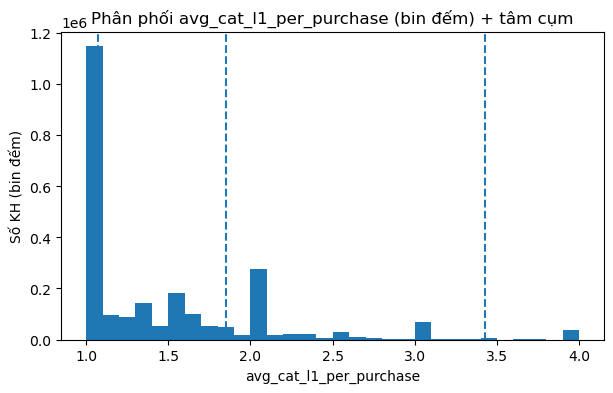

In [17]:
# Cell D (optimized)
centers_emp = cluster_summary.select("center_empirical").to_numpy().ravel()

xs, ys = hist_counts_polars(cust_avg, "avg_cat_l1_per_purchase", num_bins=30)
if xs is None:
    print("Không đủ dữ liệu để vẽ histogram cho avg_cat_l1_per_purchase.")
else:
    plt.figure(figsize=(7,4))
    plt.bar(xs, ys, width=(xs[1]-xs[0]) if len(xs)>1 else 0.1, align="center")
    vlines_for_centers(plt.gca(), centers_emp, ymin=0, ymax=1)
    plt.title("Phân phối avg_cat_l1_per_purchase (bin đếm) + tâm cụm")
    plt.xlabel("avg_cat_l1_per_purchase")
    plt.ylabel("Số KH (bin đếm)")
    plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_1464\3895665353.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(samples, labels=labels, showfliers=False)


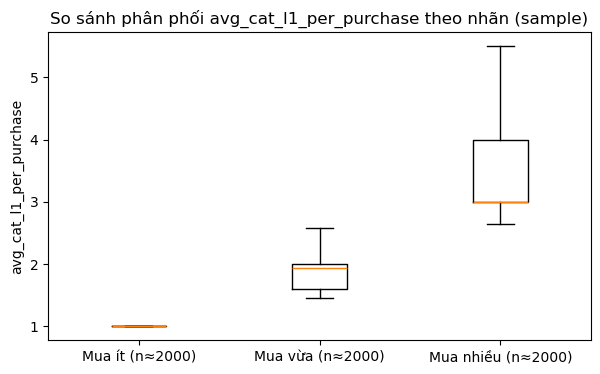

In [18]:
# Cell E (optimized)
# Để tránh materialize lớn, chỉ sample mỗi cụm tối đa N_PER điểm
N_PER = 2000
samples = []
labels = []
for r, name in [(0,"Mua ít"), (1,"Mua vừa"), (2,"Mua nhiều")]:
    sub = cust_avg.filter(pl.col("cluster_rank")==r).select("avg_cat_l1_per_purchase")
    n_sub = int(sub.height)
    if n_sub == 0:
        samples.append(np.array([]))
        labels.append(name + " (0)")
        continue
    take_n = min(N_PER, n_sub)
    # sample ngẫu nhiên ổn định
    arr = sub.sample(n=take_n, with_replacement=False, seed=42).to_numpy().ravel()
    samples.append(arr)
    labels.append(f"{name} (n≈{take_n})")

if sum(len(a)>0 for a in samples) == 0:
    print("Không đủ dữ liệu để vẽ boxplot.")
else:
    plt.figure(figsize=(7,4))
    plt.boxplot(samples, labels=labels, showfliers=False)
    plt.title("So sánh phân phối avg_cat_l1_per_purchase theo nhãn (sample)")
    plt.ylabel("avg_cat_l1_per_purchase")
    plt.show()


In [20]:
# Cell G (optimized)
def show_customer_check(cid):
    pc = purchase_cat.filter(pl.col("customer_id")==cid).select(["customer_id","created_date","n_cat_l1_per_purchase"])
    if pc.height == 0:
        print(f"(customer_id={cid}) không có lần mua nào trong purchase_cat.")
        return
    avg_true = float(pc.select(pl.col("n_cat_l1_per_purchase").mean()).to_numpy().ravel()[0])
    row = cust_avg.filter(pl.col("customer_id")==cid).select(["avg_cat_l1_per_purchase","segment_name"]).head(1)
    if row.height == 0:
        print(f"(customer_id={cid}) không tìm thấy trong cust_avg.")
        return
    avg_joined = float(row.select("avg_cat_l1_per_purchase").to_numpy().ravel()[0])
    seg = row.select("segment_name").to_numpy().ravel()[0]
    print(f"\n=== customer_id={cid} | segment={seg} ===")
    print(pc.sort("created_date").head(10))  # chỉ in 10 dòng
    print(f"Trung bình tính tay: {avg_true:.3f} | Giá trị trong cust_avg: {avg_joined:.3f}")

# Lấy tối đa 2 khách mỗi cụm để kiểm tra
for r in [0,1,2]:
    ids = (
        cust_avg.filter(pl.col("cluster_rank")==r)
                .select("customer_id")
                .head(2)  # rất nhỏ
                .to_series()
                .to_list()
    )
    for cid in ids:
        show_customer_check(cid)



=== customer_id=2760948 | segment=Mua ít ===
shape: (1, 3)
┌─────────────┬─────────────────────────┬───────────────────────┐
│ customer_id ┆ created_date            ┆ n_cat_l1_per_purchase │
│ ---         ┆ ---                     ┆ ---                   │
│ i32         ┆ datetime[μs]            ┆ u32                   │
╞═════════════╪═════════════════════════╪═══════════════════════╡
│ 2760948     ┆ 2024-07-14 08:29:57.670 ┆ 1                     │
└─────────────┴─────────────────────────┴───────────────────────┘
Trung bình tính tay: 1.000 | Giá trị trong cust_avg: 1.000

=== customer_id=6499351 | segment=Mua ít ===
shape: (10, 3)
┌─────────────┬─────────────────────────┬───────────────────────┐
│ customer_id ┆ created_date            ┆ n_cat_l1_per_purchase │
│ ---         ┆ ---                     ┆ ---                   │
│ i32         ┆ datetime[μs]            ┆ u32                   │
╞═════════════╪═════════════════════════╪═══════════════════════╡
│ 6499351     ┆ 2024-01-04 0